--- ANTRENARE ISOLATION FOREST PE GPU VIA PYTORCH (2018) ---
Dispozitiv detectat: cuda
Date încărcate în VRAM: Train=torch.Size([531046, 78]), Test=torch.Size([513705, 78])
Antrenare structură arbori pe CPU (Parallel processing)...
Antrenare structurală finalizată în 8.98 secunde.
Execuție inferență paralelă pe nucleele CUDA...
Inferență pe GPU finalizată în 3.0963s

REZULTATE ISOLATION FOREST GPU - 2018
AUC: 0.8933
Timp Antrenare Structură: 8.98s

              precision    recall  f1-score   support

      Normal       0.96      0.65      0.78    132762
    Anomalie       0.89      0.99      0.94    380943

    accuracy                           0.90    513705
   macro avg       0.92      0.82      0.86    513705
weighted avg       0.91      0.90      0.90    513705



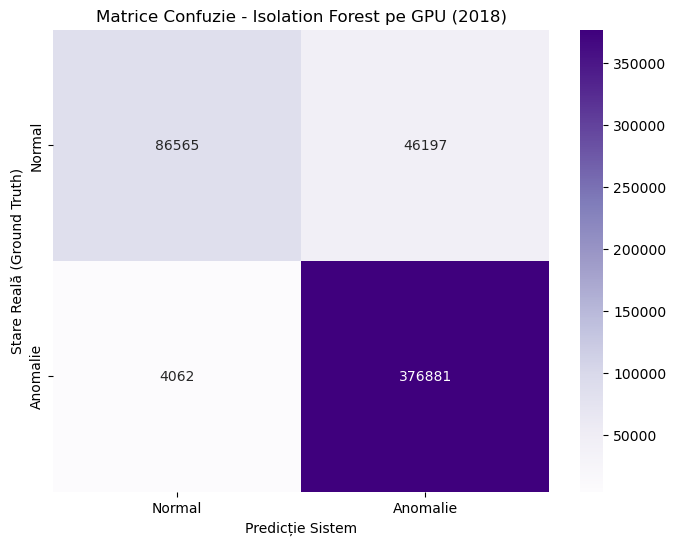

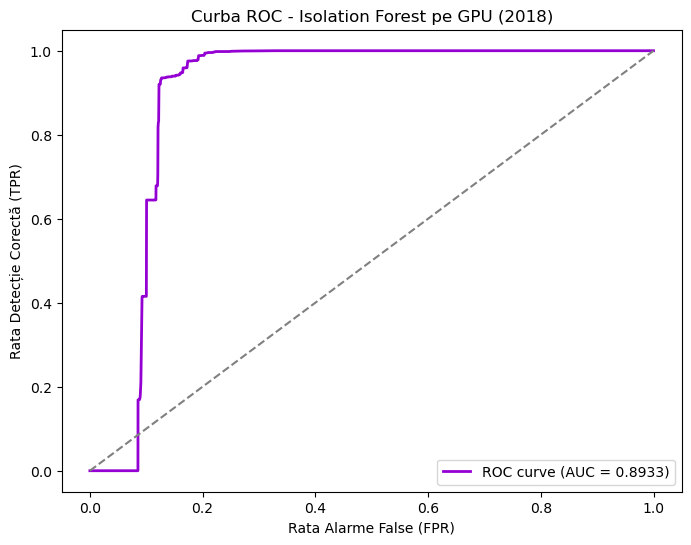

Model salvat în: D:\disertatie\modele_2018\Isolation_Forest\model_if_2018_gpu.pkl
Rezultate grafice salvate în: D:\disertatie\rezultate_2018\Isolation_Forest


In [1]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

data_path = r'D:\disertatie\preprocesare_anomalii_2018'
model_save_path = r'D:\disertatie\modele_2018\Isolation_Forest'
rezultate_path = r'D:\disertatie\rezultate_2018\Isolation_Forest'

for p in [model_save_path, rezultate_path]:
    os.makedirs(p, exist_ok=True)

print("--- ANTRENARE ISOLATION FOREST PE GPU VIA PYTORCH (2018) ---")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispozitiv detectat: {device}")

X_train_tensor = torch.load(os.path.join(data_path, 'X_train_2018.pt'), map_location=device).float()
X_test_tensor = torch.load(os.path.join(data_path, 'X_test_2018.pt'), map_location=device).float()
y_test_tensor = torch.load(os.path.join(data_path, 'y_test_2018.pt'), map_location=device)

X_train_cpu = X_train_tensor.cpu().numpy()
X_test_cpu = X_test_tensor.cpu().numpy()
y_test_cpu = y_test_tensor.cpu().numpy()

print(f"Date încărcate în VRAM: Train={X_train_tensor.shape}, Test={X_test_tensor.shape}")

model = IsolationForest(
    n_estimators=500, 
    contamination=0.35, 
    random_state=42, 
    n_jobs=-1  
)

start_time = time.time()
print("Antrenare structură arbori pe CPU (Parallel processing)...")
model.fit(X_train_cpu)
train_time = time.time() - start_time
print(f"Antrenare structurală finalizată în {train_time:.2f} secunde.")

def predict_iforest_pytorch(iforest_model, X_tensor):
    n_samples = X_tensor.shape[0]
    n_estimators = len(iforest_model.estimators_)
    paths_length = torch.zeros((n_samples, n_estimators), device=device)
    
    for i, estimator in enumerate(iforest_model.estimators_):
        tree = estimator.tree_
        left_children = torch.tensor(tree.children_left, dtype=torch.long, device=device)
        right_children = torch.tensor(tree.children_right, dtype=torch.long, device=device)
        features = torch.tensor(tree.feature, dtype=torch.long, device=device)
        thresholds = torch.tensor(tree.threshold, dtype=torch.float32, device=device)
        
        node_indicator = torch.zeros(n_samples, dtype=torch.long, device=device)
        depths = torch.zeros(n_samples, device=device)
        
        while True:
            current_features = features[node_indicator]
            is_leaf = current_features == -2
            if torch.all(is_leaf):
                break
                
            going_left = X_tensor[torch.arange(n_samples), current_features] <= thresholds[node_indicator]
            
            node_indicator = torch.where(
                is_leaf, 
                node_indicator, 
                torch.where(going_left, left_children[node_indicator], right_children[node_indicator])
            )
            depths = torch.where(is_leaf, depths, depths + 1)
            
        paths_length[:, i] = depths
        
    mean_paths = torch.mean(paths_length, dim=1)
    
    def c_factor(n):
        if n <= 1:
            return 0.0
        if n == 2:
            return 1.0
        return 2.0 * (np.log(n - 1) + 0.5772156649) - (2.0 * (n - 1) / n)
        
    c = c_factor(iforest_model.max_samples_)
    scores = -torch.pow(2.0, - (mean_paths / (c + 1e-10)))
    return scores

print("Execuție inferență paralelă pe nucleele CUDA...")
start_inference = time.time()
with torch.no_grad():
    decision_scores_tensor = predict_iforest_pytorch(model, X_test_tensor)
    decision_scores = decision_scores_tensor.cpu().numpy()
print(f"Inferență pe GPU finalizată în {time.time() - start_inference:.4f}s")

y_pred_raw = model.predict(X_test_cpu)
y_pred = [1 if x == -1 else 0 for x in y_pred_raw]

y_scores = -decision_scores 

fpr, tpr, _ = roc_curve(y_test_cpu, y_scores)
roc_auc = auc(fpr, tpr)

report = classification_report(y_test_cpu, y_pred, target_names=['Normal', 'Anomalie'])
full_report = f"REZULTATE ISOLATION FOREST GPU - 2018\nAUC: {roc_auc:.4f}\nTimp Antrenare Structură: {train_time:.2f}s\n\n{report}"
print("\n" + full_report)

with open(os.path.join(rezultate_path, 'raport_if_gpu.txt'), 'w') as f:
    f.write(full_report)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_cpu, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Normal', 'Anomalie'], yticklabels=['Normal', 'Anomalie'])
plt.ylabel('Stare Reală (Ground Truth)')
plt.xlabel('Predicție Sistem')
plt.title('Matrice Confuzie - Isolation Forest pe GPU (2018)')
plt.savefig(os.path.join(rezultate_path, 'matrice_confuzie_if_gpu.png'), dpi=300)
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkviolet', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('Rata Alarme False (FPR)')
plt.ylabel('Rata Detecție Corectă (TPR)')
plt.title('Curba ROC - Isolation Forest pe GPU (2018)')
plt.legend(loc="lower right")
plt.savefig(os.path.join(rezultate_path, 'curba_roc_if_gpu.png'), dpi=300)
plt.show()

model_file = os.path.join(model_save_path, 'model_if_2018_gpu.pkl')
joblib.dump(model, model_file)
print(f"Model salvat în: {model_file}")
print(f"Rezultate grafice salvate în: {rezultate_path}")